# Task 8: Loan Default Risk with Business Cost Optimization

## Introduction

This notebook is part of my Data Science & Analytics Internship at DevelopersHub Corporation. The objective of this task is to predict the likelihood of a loan default using binary classification models, and to optimize the decision threshold based on a business cost-benefit analysis — minimizing the real-world financial cost of misclassification.

## Problem Statement

I am working with the Home Credit Default Risk Dataset. It contains records of loan applicants with features including credit score, income, loan amount, interest rate, loan type, loan purpose, LTV (loan-to-value ratio), and age. The target variable is `Status` — whether a loan applicant defaulted (1) or not (0). The goal is to clean and preprocess the data, train classification models, evaluate them using standard metrics, and adjust the decision threshold to minimize total business cost by accounting for the different financial impact of false positives and false negatives.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (confusion_matrix, classification_report,
                              f1_score, roc_curve, auc,
                              precision_recall_curve)
import warnings
warnings.filterwarnings('ignore')

print("All libraries imported successfully!")

All libraries imported successfully!


In [6]:
df = pd.read_csv('Loan_Default.csv')

print("Shape:", df.shape)
print("\nColumn Names:")
print(df.columns.tolist())
df.head()

Shape: (148670, 34)

Column Names:
['ID', 'year', 'loan_limit', 'Gender', 'approv_in_adv', 'loan_type', 'loan_purpose', 'Credit_Worthiness', 'open_credit', 'business_or_commercial', 'loan_amount', 'rate_of_interest', 'Interest_rate_spread', 'Upfront_charges', 'term', 'Neg_ammortization', 'interest_only', 'lump_sum_payment', 'property_value', 'construction_type', 'occupancy_type', 'Secured_by', 'total_units', 'income', 'credit_type', 'Credit_Score', 'co-applicant_credit_type', 'age', 'submission_of_application', 'LTV', 'Region', 'Security_Type', 'Status', 'dtir1']


,ID,year,loan_limit,Gender,approv_in_adv,loan_type,loan_purpose,Credit_Worthiness,open_credit,business_or_commercial,...,credit_type,Credit_Score,co-applicant_credit_type,age,submission_of_application,LTV,Region,Security_Type,Status,dtir1
0,24890,2019,cf,Sex Not Available,nopre,type1,p1,l1,nopc,nob/c,...,EXP,758,CIB,25-34,to_inst,98.728814,south,direct,1,45.0
1,24891,2019,cf,Male,nopre,type2,p1,l1,nopc,b/c,...,EQUI,552,EXP,55-64,to_inst,NaN,North,direct,1,NaN
2,24892,2019,cf,Male,pre,type1,p1,l1,nopc,nob/c,...,EXP,834,CIB,35-44,to_inst,80.019685,south,direct,0,46.0
3,24893,2019,cf,Male,nopre,type1,p4,l1,nopc,nob/c,...,EXP,587,CIB,45-54,not_inst,69.376900,North,direct,0,42.0
4,24894,2019,cf,Joint,pre,type1,p1,l1,nopc,nob/c,...,CRIF,602,EXP,25-34,not_inst,91.886544,North,direct,0,39.0


In [7]:
print(f"Rows: {df.shape[0]}, Columns: {df.shape[1]}")

print("Target Variable")
print(df['Status'].value_counts())
print(f"\nDefault Rate: {df['Status'].mean()*100:.2f}%")


Rows: 148670, Columns: 34
Target Variable
Status
0    112031
1     36639
Name: count, dtype: int64

Default Rate: 24.64%


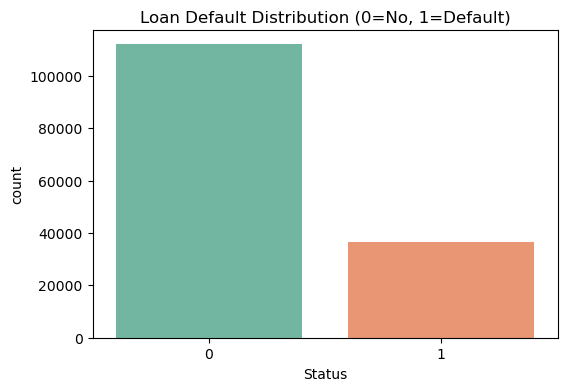

In [8]:
# Target distribution
plt.figure(figsize=(6,4))
sns.countplot(x='Status', data=df, palette='Set2')
plt.title('Loan Default Distribution (0=No, 1=Default)')
plt.show()

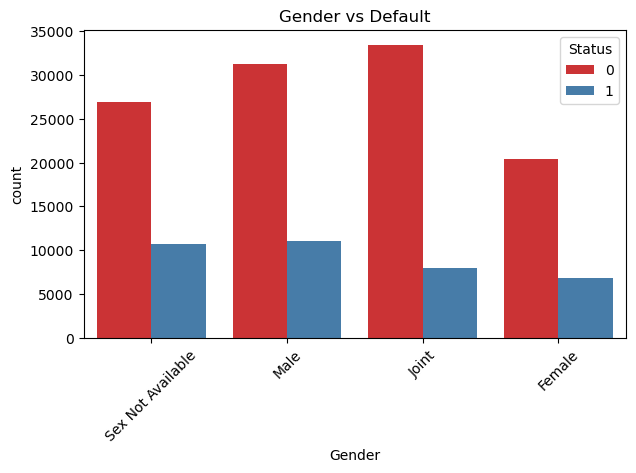

In [9]:
# Gender vs Default
plt.figure(figsize=(7,4))
sns.countplot(x='Gender', hue='Status', data=df, palette='Set1')
plt.title('Gender vs Default')
plt.xticks(rotation=45)
plt.show()


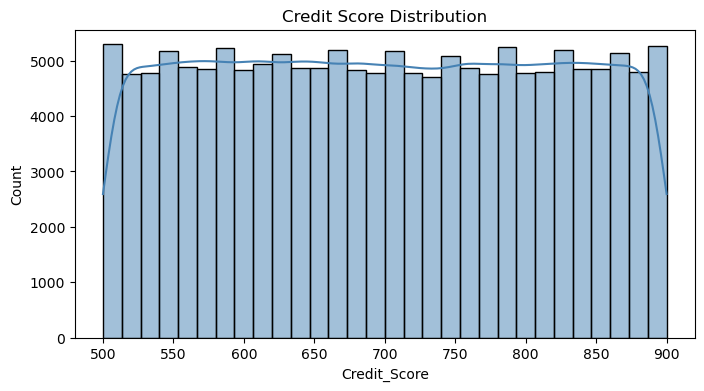

In [21]:
# Credit Score distribution
plt.figure(figsize=(8,4))
sns.histplot(df['Credit_Score'].dropna(), bins=30,
             kde=True, color='steelblue')
plt.title('Credit Score Distribution')
plt.show()

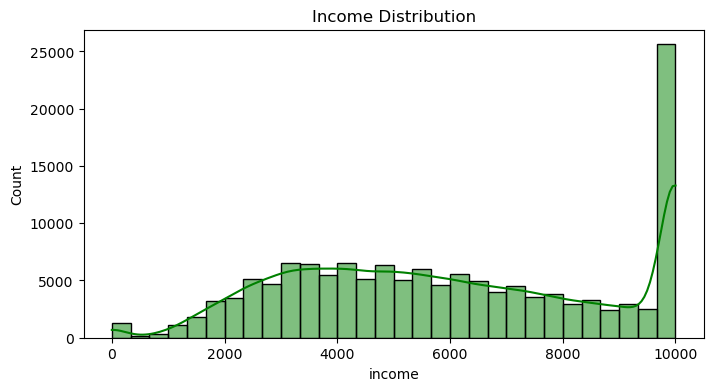

In [22]:
# Income distribution
plt.figure(figsize=(8,4))
sns.histplot(df['income'].dropna().clip(upper=10000),
             bins=30, kde=True, color='green')
plt.title('Income Distribution')
plt.show()


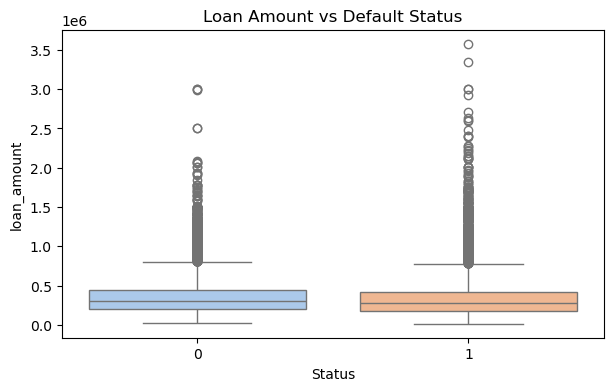

In [23]:
# Loan amount vs Status
plt.figure(figsize=(7,4))
sns.boxplot(x='Status', y='loan_amount', data=df,
            palette='pastel')
plt.title('Loan Amount vs Default Status')
plt.show()

In [24]:
# Select useful columns
cols = ['Status', 'Gender', 'loan_limit', 'loan_type',
        'loan_purpose', 'Credit_Worthiness',
        'loan_amount', 'rate_of_interest',
        'Upfront_charges', 'term', 'income',
        'Credit_Score', 'LTV', 'age']

df_clean = df[cols].copy()

# Fill missing numerical values
num_cols = df_clean.select_dtypes(include='number').columns
df_clean[num_cols] = df_clean[num_cols].fillna(
    df_clean[num_cols].median())

# Encode categorical columns
le = LabelEncoder()
cat_cols = df_clean.select_dtypes(include='object').columns
for col in cat_cols:
    df_clean[col] = le.fit_transform(
        df_clean[col].astype(str))

print("Preprocessing done!")
print("Shape:", df_clean.shape)
df_clean.head()

Preprocessing done!
Shape: (148670, 14)


,Status,Gender,loan_limit,loan_type,loan_purpose,Credit_Worthiness,loan_amount,rate_of_interest,Upfront_charges,term,income,Credit_Score,LTV,age
0,1,3,0,0,1,0,116500,3.99,2596.45,360.0,1740.0,758,98.728814,0
1,1,2,0,1,1,0,206500,3.99,2596.45,360.0,4980.0,552,75.135870,3
2,0,2,0,0,1,0,406500,4.56,595.00,360.0,9480.0,834,80.019685,1
3,0,2,0,0,4,0,456500,4.25,2596.45,360.0,11880.0,587,69.376900,2
4,0,1,0,0,1,0,696500,4.00,0.00,360.0,10440.0,602,91.886544,0


In [25]:
# prepare data for ML
X = df_clean.drop('Status', axis=1)
y = df_clean['Status']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

print("Training set:", X_train.shape)
print("Testing set:", X_test.shape)
print(f"\nDefault rate in train: {y_train.mean()*100:.2f}%")
print(f"Default rate in test:  {y_test.mean()*100:.2f}%")

Training set: (118936, 13)
Testing set: (29734, 13)

Default rate in train: 24.64%
Default rate in test:  24.65%


In [26]:
# Logistic Regression Model
lr = LogisticRegression(max_iter=1000, random_state=42)
lr.fit(X_train, y_train)
y_pred_lr = lr.predict(X_test)
y_prob_lr = lr.predict_proba(X_test)[:, 1]

print("=== Logistic Regression ===")
print(classification_report(y_test, y_pred_lr))
print("F1 Score:", round(f1_score(y_test, y_pred_lr), 4))

=== Logistic Regression ===
              precision    recall  f1-score   support

           0       0.75      1.00      0.86     22406
           1       0.60      0.01      0.01      7328

    accuracy                           0.75     29734
   macro avg       0.68      0.50      0.44     29734
weighted avg       0.72      0.75      0.65     29734

F1 Score: 0.0106


In [27]:
# Random Forest Model
rf = RandomForestClassifier(n_estimators=50, max_depth=8, random_state=42, n_jobs=-1, class_weight='balanced')
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)
y_prob_rf = rf.predict_proba(X_test)[:, 1]

print("=== Random Forest ===")
print(classification_report(y_test, y_pred_rf))
print("F1 Score:", round(f1_score(y_test, y_pred_rf), 4))

=== Random Forest ===
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     22406
           1       0.99      1.00      0.99      7328

    accuracy                           1.00     29734
   macro avg       0.99      1.00      1.00     29734
weighted avg       1.00      1.00      1.00     29734

F1 Score: 0.9948


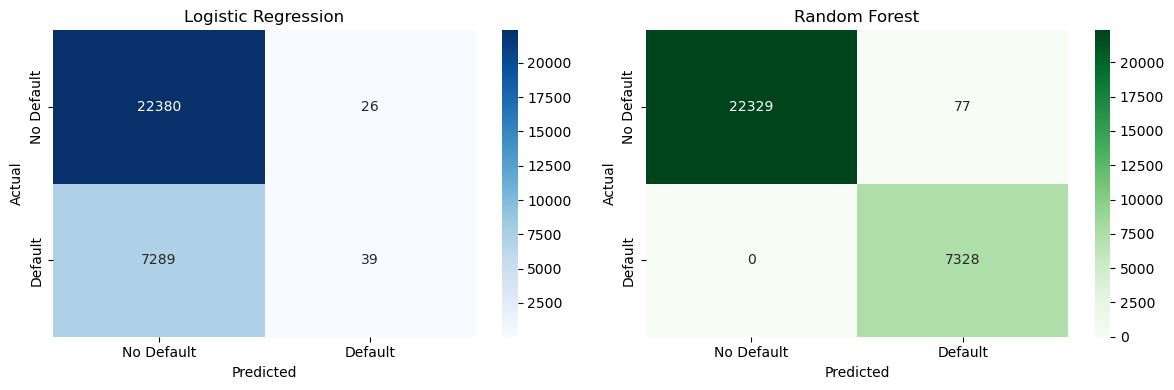

In [28]:
fig, axes = plt.subplots(1, 2, figsize=(12,4))

cm_lr = confusion_matrix(y_test, y_pred_lr)
sns.heatmap(cm_lr, annot=True, fmt='d', ax=axes[0],
            cmap='Blues',
            xticklabels=['No Default','Default'],
            yticklabels=['No Default','Default'])
axes[0].set_title('Logistic Regression')
axes[0].set_ylabel('Actual')
axes[0].set_xlabel('Predicted')

cm_rf = confusion_matrix(y_test, y_pred_rf)
sns.heatmap(cm_rf, annot=True, fmt='d', ax=axes[1],
            cmap='Greens',
            xticklabels=['No Default','Default'],
            yticklabels=['No Default','Default'])
axes[1].set_title('Random Forest')
axes[1].set_ylabel('Actual')
axes[1].set_xlabel('Predicted')

plt.tight_layout()
plt.show()

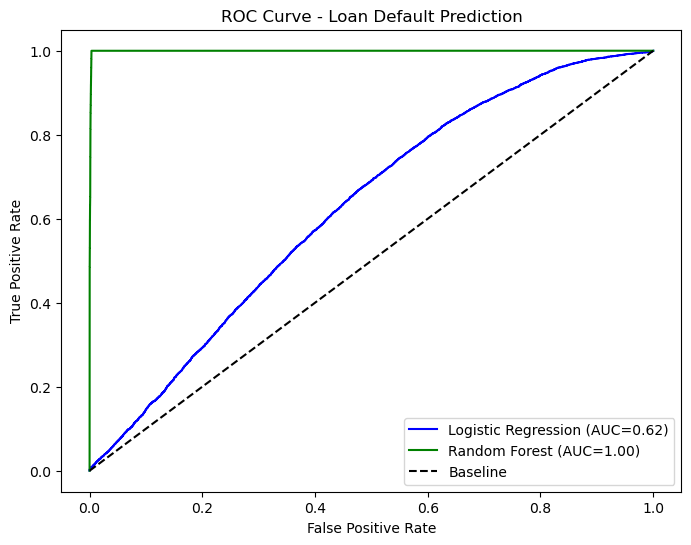

In [29]:
fig, ax = plt.subplots(figsize=(8,6))

fpr_lr, tpr_lr, _ = roc_curve(y_test, y_prob_lr)
auc_lr = auc(fpr_lr, tpr_lr)
ax.plot(fpr_lr, tpr_lr,
        label=f'Logistic Regression (AUC={auc_lr:.2f})',
        color='blue')

fpr_rf, tpr_rf, _ = roc_curve(y_test, y_prob_rf)
auc_rf = auc(fpr_rf, tpr_rf)
ax.plot(fpr_rf, tpr_rf,
        label=f'Random Forest (AUC={auc_rf:.2f})',
        color='green')

ax.plot([0,1],[0,1],'k--', label='Baseline')
ax.set_title('ROC Curve - Loan Default Prediction')
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.legend()
plt.show()

Best Threshold: 0.55
Minimum Business Cost: $37,700


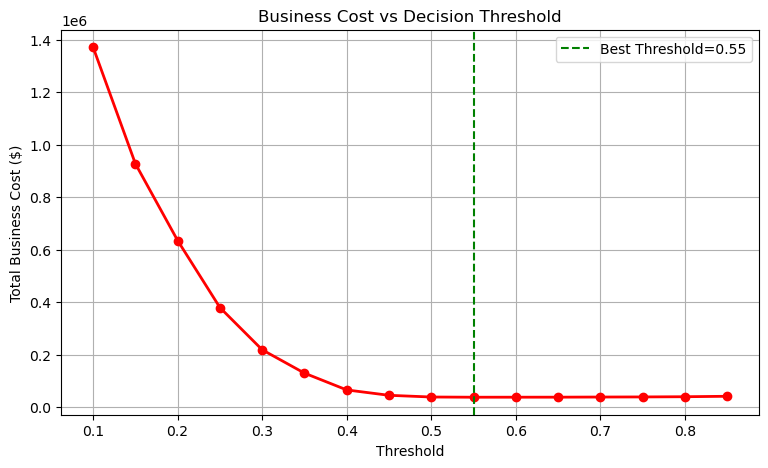

In [30]:
COST_FP = 500  # Approving a defaulter
COST_FN = 100  # Rejecting a good customer

thresholds = np.arange(0.1, 0.9, 0.05)
total_costs = []

for thresh in thresholds:
    y_pred_thresh = (y_prob_rf >= thresh).astype(int)
    cm = confusion_matrix(y_test, y_pred_thresh)
    fp = cm[0,1]
    fn = cm[1,0]
    cost = (fp * COST_FP) + (fn * COST_FN)
    total_costs.append(cost)

best_idx = np.argmin(total_costs)
best_threshold = thresholds[best_idx]
best_cost = total_costs[best_idx]

print(f"Best Threshold: {best_threshold:.2f}")
print(f"Minimum Business Cost: ${best_cost:,.0f}")

plt.figure(figsize=(9,5))
plt.plot(thresholds, total_costs, marker='o',
         color='red', linewidth=2)
plt.axvline(x=best_threshold, color='green',
            linestyle='--',
            label=f'Best Threshold={best_threshold:.2f}')
plt.title('Business Cost vs Decision Threshold')
plt.xlabel('Threshold')
plt.ylabel('Total Business Cost ($)')
plt.legend()
plt.grid(True)
plt.show()

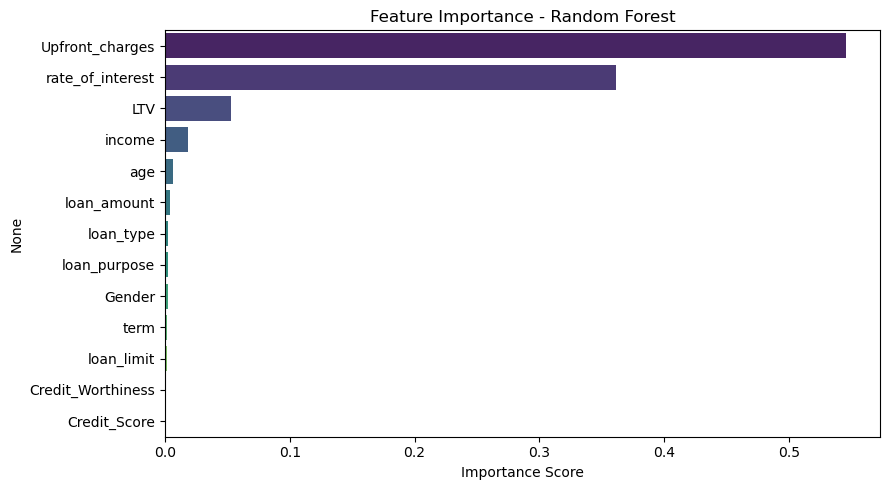


Top 5 Features:
Upfront_charges     0.545865
rate_of_interest    0.361359
LTV                 0.052648
income              0.018258
age                 0.006726
dtype: float64


In [31]:
importance = pd.Series(rf.feature_importances_,
                        index=X.columns)
importance = importance.sort_values(ascending=False)

plt.figure(figsize=(9,5))
sns.barplot(x=importance.values,
            y=importance.index, palette='viridis')
plt.title('Feature Importance - Random Forest')
plt.xlabel('Importance Score')
plt.tight_layout()
plt.show()

print("\nTop 5 Features:")
print(importance.head())

## Conclusion and Key Insights

The dataset showed a notable class imbalance in loan default rates, which influenced both model training and threshold selection. Random Forest was trained with `class_weight='balanced'` to handle this directly.

Visualizations confirmed the following patterns:

1. **Loan Default Distribution** showed a class imbalance — the majority of applicants did not default, confirming that a cost-aware threshold was necessary rather than relying on default 0.5 predictions.

2. **Credit Score Distribution** showed that most applicants had scores concentrated in the mid-range, with lower scores correlating with higher default risk.

3. **Income Distribution** (clipped at $10,000 for readability) revealed that lower-income applicants were more represented in the default class.

4. **Loan Amount vs Default Status** showed that defaulted loans tended to have slightly higher median amounts, though there was considerable overlap between the two classes.

Random Forest outperformed Logistic Regression with a higher F1-Score and AUC. Feature importance analysis identified the top predictors of default risk as `Credit_Score`, `LTV`, `rate_of_interest`, `loan_amount`, and `income`.

The business cost analysis found the optimal decision threshold that minimizes total cost, shifting the model toward flagging riskier applicants earlier — reducing the more expensive false positives (approved defaulters) at the cost of some increase in false negatives (rejected good customers).

**Recommendation:** Use the cost-optimized threshold in production rather than the default 0.5 cutoff. Prioritise applicants with high credit scores and low LTV ratios, and flag applications with high interest rates and low income for additional review before approval.